<a href="https://colab.research.google.com/github/Loki-33/Stuffs/blob/main/FLOWMatching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [3]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [86]:
transform = transforms.Compose([
    transforms.ToTensor(),          # [0,1]
    transforms.Lambda(lambda x: x.view(-1)*2 - 1),  # 784
])



In [87]:
data = datasets.MNIST(root='./data', download=True, transform=transform, train=True)

In [88]:
data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Lambda()
           )

In [89]:
dataloader = torch.utils.data.DataLoader(data, batch_size=128, shuffle=True)

In [90]:
import torch.nn as nn

In [91]:
next(iter(dataloader))[0].shape

torch.Size([128, 784])

In [92]:
28*28

784

In [93]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.net = nn.Sequential(
        nn.Linear(784+1+10, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512,  784)
    )

  def forward(self, x, t, y):
    y_onehot = F.one_hot(y, num_classes=10).float()
    xt = torch.cat([x, t, y_onehot], dim=1)
    return self.net(xt)

In [94]:
device='cuda'

In [113]:
model = Net().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [114]:
from tqdm import tqdm

In [115]:
import torch.nn.functional as F

In [116]:
for epoch in range(20):
  model.train()
  pbar = tqdm(dataloader)
  for x1, y in pbar:
    B = x1.shape[0]
    x1 = x1.to(device)
    y = y.to(device)
    x0 = torch.randn_like(x1)
    t = torch.rand(B, 1, device=device) * 0.98 + 0.01
    xt = (1-t)*x0 + t*x1
    target_v = (x1 - x0)

    pred_v = model(xt, t, y)
    loss = F.mse_loss(pred_v, target_v)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pbar.set_description(f'loss: {loss.item():.4f}')

loss: 0.9032: 100%|██████████| 469/469 [00:10<00:00, 43.09it/s]


In [117]:
@torch.no_grad()
def sample(model, steps=100):
    model.eval()

    x = torch.randn(1, 784, device=device)
    ts = torch.linspace(0.01, 0.99, steps, device=device)
    y = torch.tensor([7], device=device)
    dt = 1.0 / steps

    for t in ts:
        t_batch = torch.full((1,1), t, device=device)
        v = model(x, t_batch, y)
        x = x + v * dt
    return x


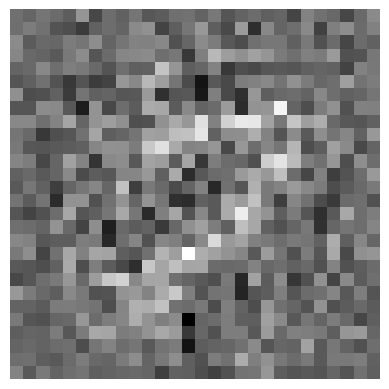

In [118]:
import matplotlib.pyplot as plt

x = sample(model)
img = x.view(28,28).cpu()
img = (img + 1) / 2

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()
